# TNT vs. DYNAMITE: orbit start spaces

Compares TNT's three orbit samplers (`StationaryGrid` for box orbits,
`XZGridFromBoundary` for boundary-searched tube orbits) against DYNAMITE's
compiled `orbitstart` binary, across four NGC6278-based viewing geometries
(oblate, mild/strong triaxial, near-prolate).

Reads the saved comparison from `results/` (produced by `run_comparison.py`)
-- this notebook only visualises it, it doesn't recompute anything.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

RESULTS = Path("results")
GEOMETRIES = ["oblate", "mild_triaxial", "strong_triaxial", "near_prolate"]

summary = json.loads((RESULTS / "summary.json").read_text())
arrays = {}
for name in GEOMETRIES:
    arrays[name] = {
        key: np.load(RESULTS / f"{name}_{key}.npy")
        for key in ("box_tnt", "box_dynamite", "tube_tnt", "tube_dynamite")
    }
summary

[{'geometry': 'oblate',
  'box_median_relative_error': 2.882300553169441e-07,
  'box_max_relative_error': 4.286565006922293e-06,
  'tube_median_relative_error': 4.938282663072615e-05,
  'tube_max_relative_error': 0.03102753930907307},
 {'geometry': 'mild_triaxial',
  'box_median_relative_error': 2.942925253381909e-07,
  'box_max_relative_error': 4.594435734108554e-06,
  'tube_median_relative_error': 7.58049903472451e-05,
  'tube_max_relative_error': 0.03103351900405835},
 {'geometry': 'strong_triaxial',
  'box_median_relative_error': 3.540318576839961e-07,
  'box_max_relative_error': 4.163097604890362e-06,
  'tube_median_relative_error': 7.848277567202466e-05,
  'tube_max_relative_error': 0.031030612260755847},
 {'geometry': 'near_prolate',
  'box_median_relative_error': 4.045880300234327e-07,
  'box_max_relative_error': 4.588611458747298e-06,
  'tube_median_relative_error': 1.0894683112895046e-05,
  'tube_max_relative_error': 0.03103017966632289}]

## Box orbits: `(x, z)` starting positions

Each panel is one energy shell (outermost at top), one geometry per column.
TNT (pale, larger, drawn first) and DYNAMITE (solid, smaller, drawn on top)
should land on the same points.

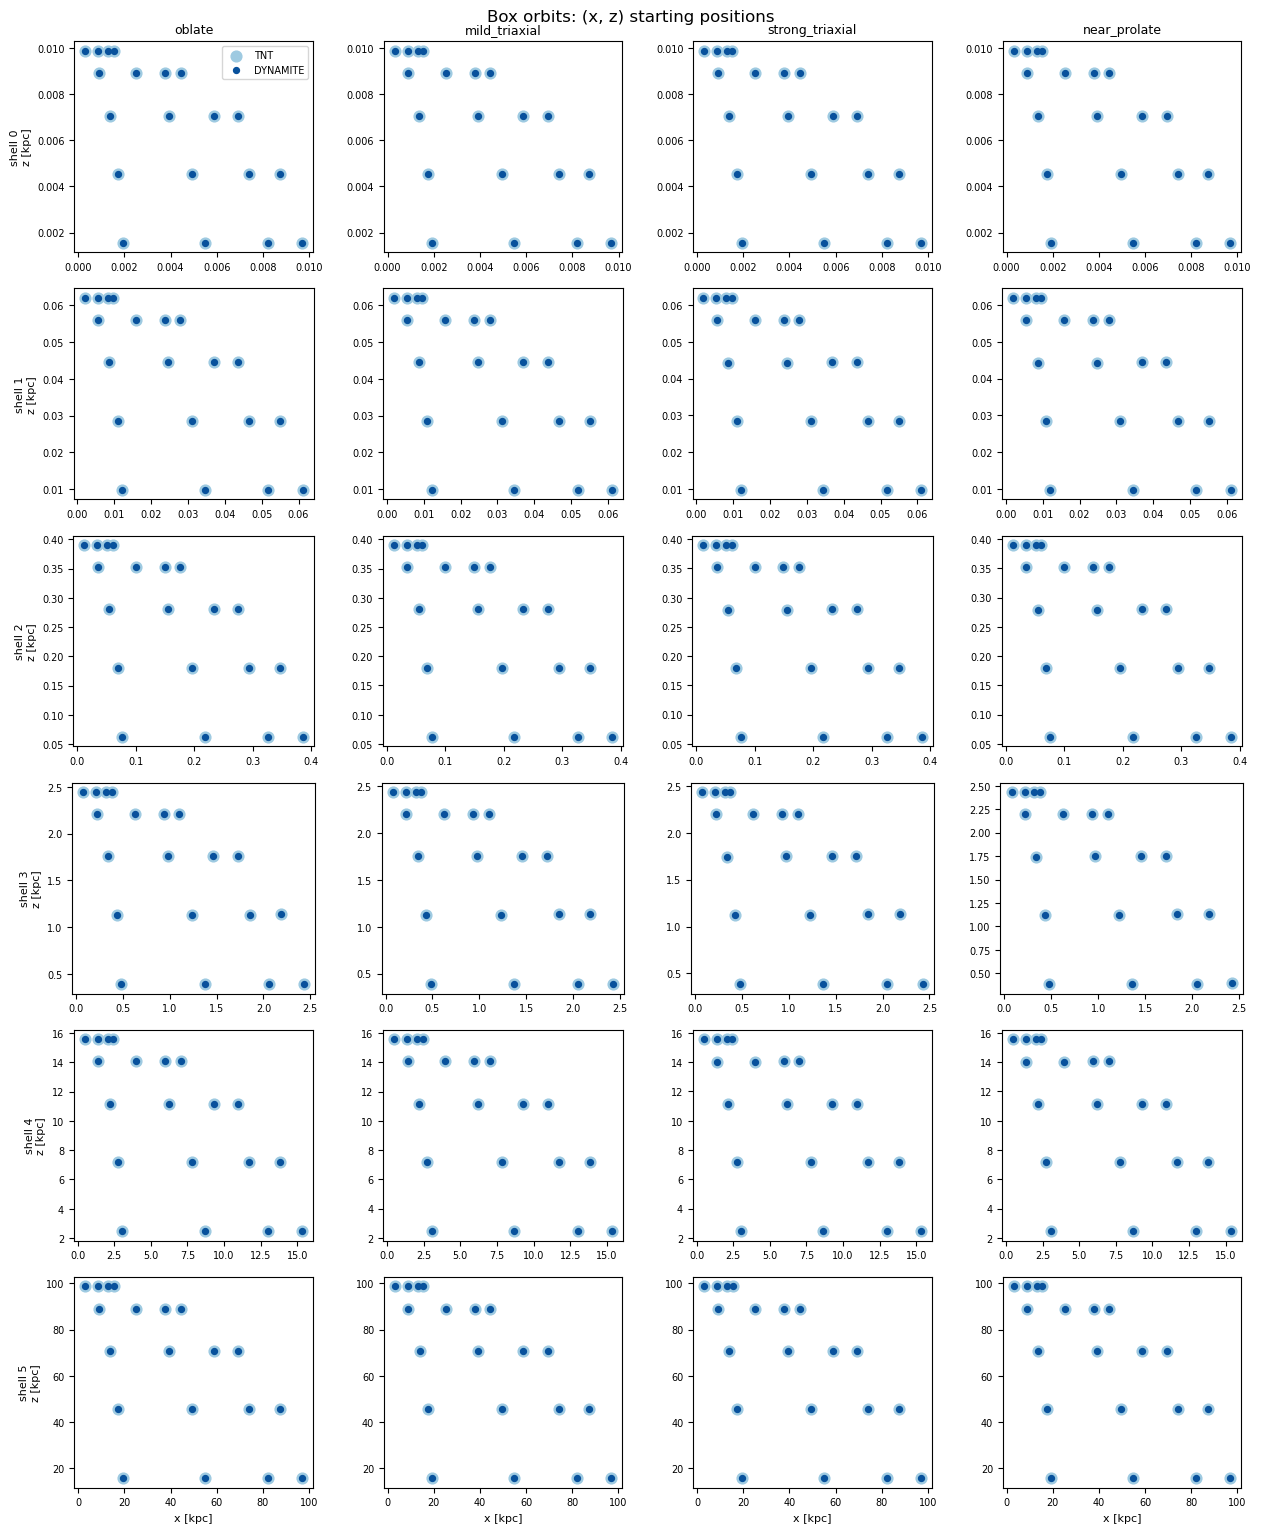

In [2]:
def plot_xz_grid(key_tnt, key_dyn, title):
    nE = arrays[GEOMETRIES[0]][key_tnt].shape[0]
    fig, axes = plt.subplots(
        nE, len(GEOMETRIES), figsize=(3.2 * len(GEOMETRIES), 2.6 * nE),
        squeeze=False,
    )
    for col, name in enumerate(GEOMETRIES):
        tnt = arrays[name][key_tnt]
        dyn = arrays[name][key_dyn]
        for shell in range(nE):
            ax = axes[shell, col]
            x_t, z_t = tnt[shell, ..., 0].ravel(), tnt[shell, ..., 2].ravel()
            x_d, z_d = dyn[shell, ..., 0].ravel(), dyn[shell, ..., 2].ravel()
            ax.scatter(x_t, z_t, s=60, color="#9ecae1", label="TNT", zorder=1)
            ax.scatter(x_d, z_d, s=18, color="#08519c", label="DYNAMITE", zorder=2)
            ax.set_aspect("equal")
            if shell == 0:
                ax.set_title(name, fontsize=9)
            if col == 0:
                ax.set_ylabel(f"shell {shell}\nz [kpc]", fontsize=8)
            if shell == nE - 1:
                ax.set_xlabel("x [kpc]", fontsize=8)
            ax.tick_params(labelsize=7)
    axes[0, 0].legend(fontsize=7, loc="upper right")
    fig.suptitle(title)
    fig.tight_layout()
    return fig


plot_xz_grid("box_tnt", "box_dynamite", "Box orbits: (x, z) starting positions")
plt.show()

## Tube orbits: `(x, z)` starting positions

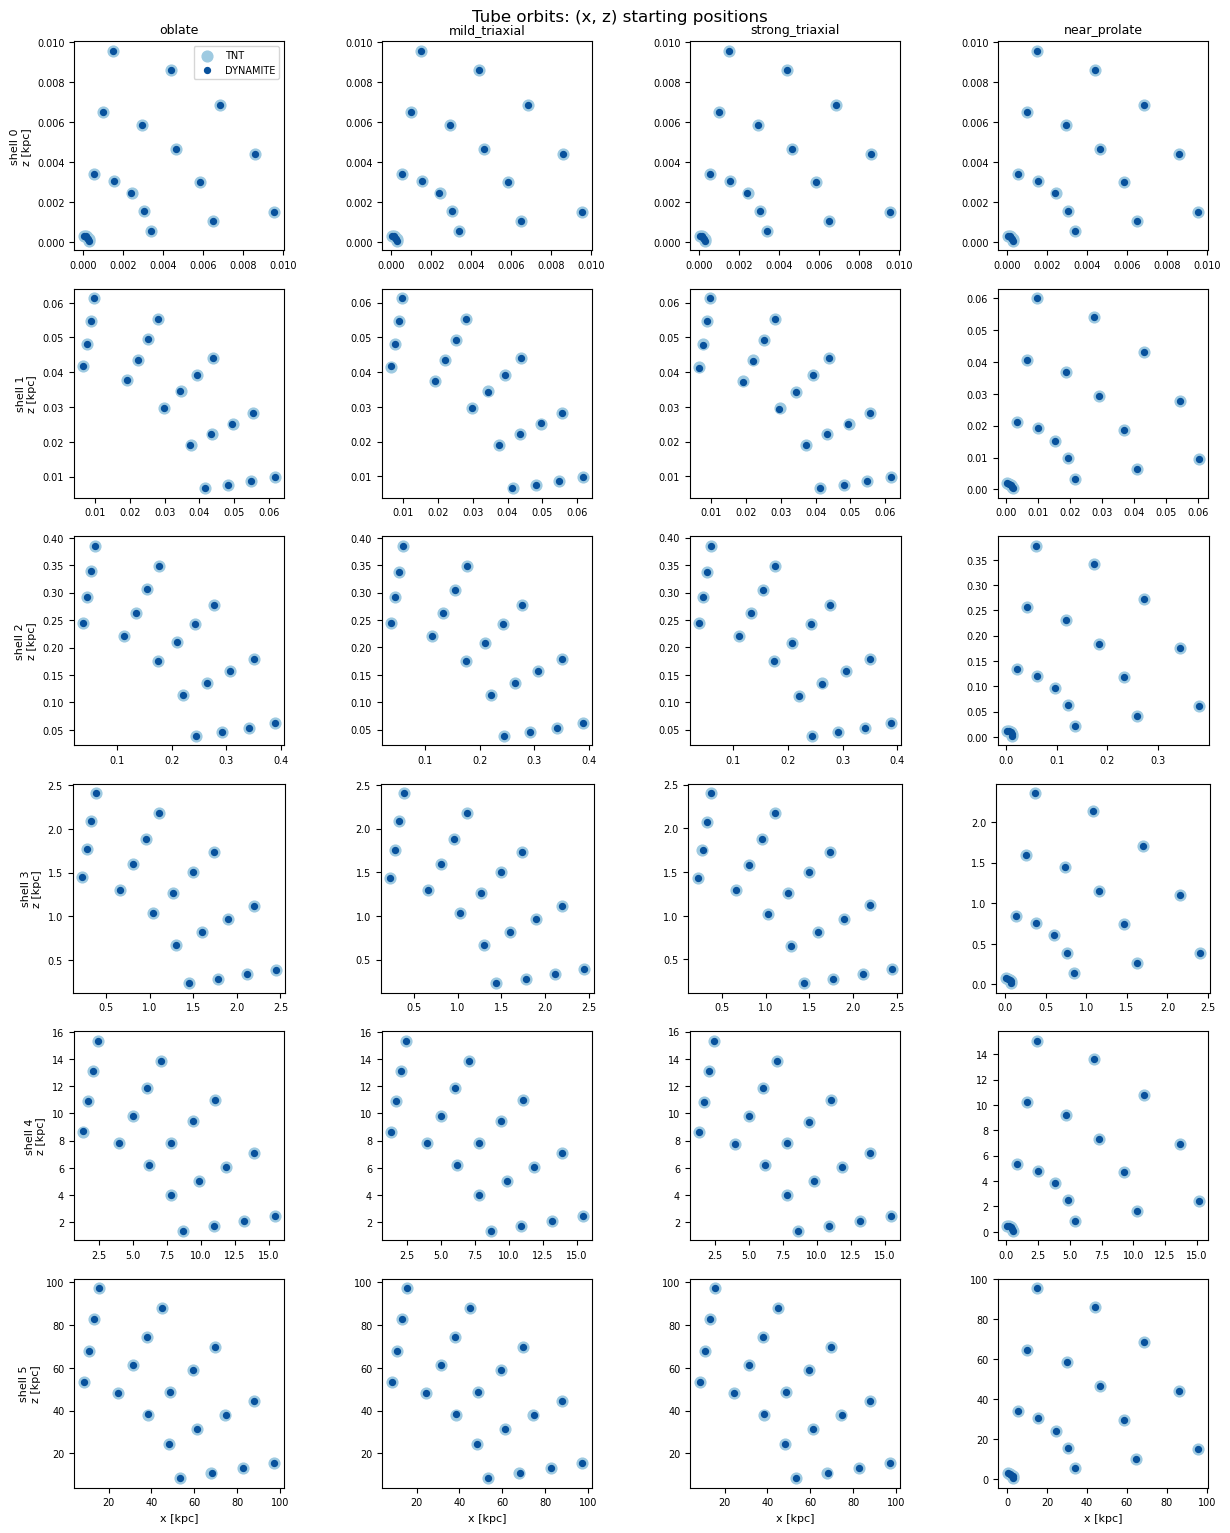

In [3]:
plot_xz_grid("tube_tnt", "tube_dynamite", "Tube orbits: (x, z) starting positions")
plt.show()

## Tube orbits: `v_y` agreement

Each point is one bundle; the diagonal is exact agreement.

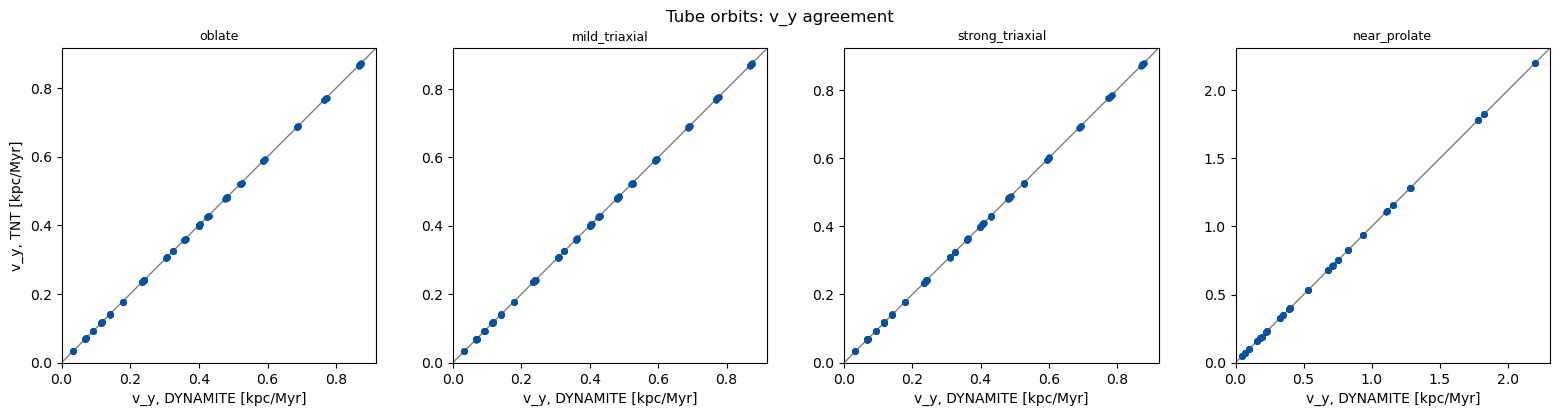

In [4]:
fig, axes = plt.subplots(1, len(GEOMETRIES), figsize=(4 * len(GEOMETRIES), 4))
for ax, name in zip(axes, GEOMETRIES):
    v_tnt = arrays[name]["tube_tnt"][..., 4].ravel()
    v_dyn = arrays[name]["tube_dynamite"][..., 4].ravel()
    lim = max(v_tnt.max(), v_dyn.max()) * 1.05
    ax.plot([0, lim], [0, lim], color="gray", linewidth=1, zorder=1)
    ax.scatter(v_dyn, v_tnt, s=14, color="#08519c", zorder=2)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_aspect("equal")
    ax.set_xlabel("v_y, DYNAMITE [kpc/Myr]")
    ax.set_title(name, fontsize=9)
axes[0].set_ylabel("v_y, TNT [kpc/Myr]")
fig.suptitle("Tube orbits: v_y agreement")
fig.tight_layout()
plt.show()

## Relative error summary

Median and max relative error per geometry (box: position only; tube:
position and `v_y`). Log scale -- note the box orbits are roughly two
orders of magnitude more accurate than the tube orbits' typical (median)
case, and the tube orbits' single worst case (innermost shell, near the
`r_floor` origin, where a small absolute difference is a large relative
one) is consistently around 3%, not a sign of a shell-by-shell problem.

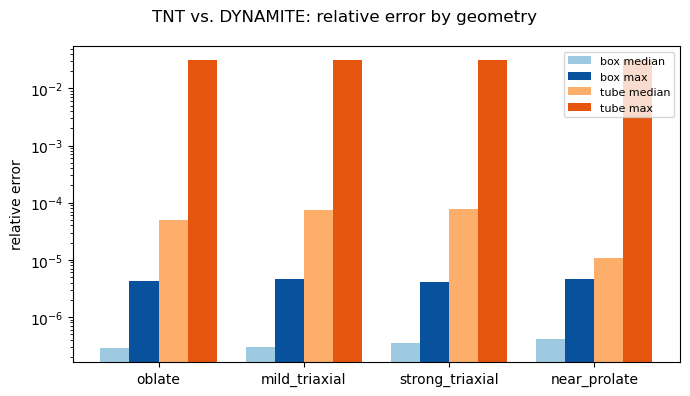

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(GEOMETRIES))
width = 0.2
metrics = [
    ("box_median_relative_error", "box median", "#9ecae1"),
    ("box_max_relative_error", "box max", "#08519c"),
    ("tube_median_relative_error", "tube median", "#fdae6b"),
    ("tube_max_relative_error", "tube max", "#e6550d"),
]
for i, (key, label, color) in enumerate(metrics):
    values = [row[key] for row in summary]
    ax.bar(x + (i - 1.5) * width, values, width, label=label, color=color)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(GEOMETRIES)
ax.set_ylabel("relative error")
ax.legend(fontsize=8)
fig.suptitle("TNT vs. DYNAMITE: relative error by geometry")
fig.tight_layout()
plt.show()